In [1]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
import gzip
import json
import re
import urllib.request
import os
from collections import defaultdict, Counter
from textblob import TextBlob
from openai import OpenAI
from getpass import getpass

In [3]:
# OPENAI_API_KEY
print("Insertar el API Key de OpenAI")
openai_key = getpass()

Insertar el API Key de OpenAI
··········


In [9]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small",#"text-embedding-3-small",
    openai_api_key=openai_key
)

docs = [
        "La gata maulla mucho y por eso se fue a la veterinaria",
        "La gata se enfermó y la llevaron a la veterinaria",
        "La gata me sirvió para cambiar la llanta",
        "hi",
        "Laptop HP 17 pulgadas, color gris"
    ]

embeddings = embeddings_model.embed_documents(docs)

print(f"Cantidad de embeddings: {len(embeddings)}")
print(f"Tamaño de cada oracion: {len(docs[3])}")
print(f"Tamaño de cada embedding: {len(embeddings[3])}")

Cantidad de embeddings: 5
Tamaño de cada oracion: 2
Tamaño de cada embedding: 1536


In [10]:
print(embeddings[4])

[-0.043243408203125, -0.0159912109375, -0.02069091796875, 0.020660400390625, -0.0281829833984375, -0.040771484375, -0.0150146484375, 0.034454345703125, -0.038330078125, 0.00452423095703125, 0.0137481689453125, -0.0165557861328125, -0.043487548828125, 0.01503753662109375, -0.004856109619140625, 0.052093505859375, -0.04150390625, -0.01788330078125, -0.07666015625, 0.03167724609375, -0.023345947265625, 0.00897979736328125, 0.0036754608154296875, -0.03338623046875, 0.028778076171875, 0.00028014183044433594, -0.010162353515625, -0.024078369140625, -0.007183074951171875, -0.01261138916015625, -0.01473236083984375, -0.036773681640625, 0.0235443115234375, -0.053619384765625, 0.0146942138671875, -0.038116455078125, -0.00240325927734375, 0.023193359375, -0.00946044921875, 0.0187530517578125, -0.0253753662109375, -0.0017480850219726562, 0.027069091796875, 0.0054931640625, 0.039398193359375, 0.00457000732421875, -0.0281829833984375, -0.0204620361328125, -0.0151824951171875, -0.00432586669921875, -

In [12]:
print(cosine_similarity_simple(embeddings[0], embeddings[1]))

0.727961957801768


In [13]:
print(cosine_similarity_simple(embeddings[0], embeddings[2]))

0.5779901939842212


In [14]:
print(cosine_similarity_simple(embeddings[0], embeddings[3]))

0.01713638167549432


In [ ]:
print(embeddings[0])


In [ ]:
print(embeddings[3])

In [ ]:
distancia = cosine_similarity_simple(embeddings[0], embeddings[1])
print(distancia)

In [ ]:
distancia = cosine_similarity_simple(embeddings[0], embeddings[2])
print(distancia)

In [ ]:
distancia_0_1 = cosine_similarity_simple(embeddings[0], embeddings[1])
distancia_0_2 = cosine_similarity_simple(embeddings[0], embeddings[2])
distancia_1_2 = cosine_similarity_simple(embeddings[1], embeddings[2])

print(f"distancia_0_1: {distancia_0_1}")
print(f"distancia_0_2: {distancia_0_2}")
print(f"distancia_1_2: {distancia_1_2}")

In [ ]:
print(embeddings[0])

In [ ]:
print(embeddings[1])

In [15]:
# Configuración visual
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [16]:
# Dataset de textos con similitudes léxicas pero diferentes significados
texts = [
    # Grupo 1: "banco" - institución financiera vs asiento
    "Fui al banco a depositar mi dinero en la cuenta de ahorros",
    "Tengo mis ahorros en el banco, siempre voy a depositarlo",
    "Me senté en el banco del parque a descansar un momento",
    "El banco central subió las tasas de interés este mes",
    "Construí un banco de madera para el jardín",

    # Grupo 2: "gato" - animal vs herramienta
    "Mi gato negro duerme en el sofá toda la tarde",
    "Necesito un gato hidráulico para cambiar la llanta del carro",
    "El gato de mi vecina es muy cariñoso y juguetón",
    "El mecánico usó el gato para levantar el vehículo",

    # Grupo 3: "capital" - ciudad vs dinero
    "París es la capital de Francia y una ciudad hermosa",
    "Necesito más capital para invertir en mi negocio",
    "La capital del país tiene muchos monumentos históricos",
    "El capital inicial fue suficiente para empezar la empresa",

    # Grupo 4: "red" - internet vs color/malla
    "La red de internet está muy lenta hoy en casa",
    "Compré una red de pescar para ir al lago",
    "Mi computadora no se conecta a la red wifi",
    "Los pescadores lanzaron la red al mar temprano",

    # Grupo 5: "planta" - vegetal vs fábrica/piso
    "Esta planta verde necesita más agua y luz solar",
    "La planta industrial produce miles de productos diarios",
    "Mi oficina está en la planta baja del edificio",
    "Regalé una planta de flores a mi madre"
]

print(f"Total de textos: {len(texts)}")
print("\nPrimeros 5 textos:")
for i, text in enumerate(texts[:5]):
    print(f"{i+1}: {text}")

Total de textos: 21

Primeros 5 textos:
1: Fui al banco a depositar mi dinero en la cuenta de ahorros
2: Tengo mis ahorros en el banco, siempre voy a depositarlo
3: Me senté en el banco del parque a descansar un momento
4: El banco central subió las tasas de interés este mes
5: Construí un banco de madera para el jardín


# TF-IDF

In [19]:
print("IMPLEMENTANDO TF-IDF")
print("="*50)

# Crear y entrenar el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=1,
    max_df=0.8,
    stop_words='english',
    ngram_range=(1, 2)  # incluir bigramas
)

# Obtener la matriz TF-IDF
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
print(f"Forma de la matriz TF-IDF: {tfidf_matrix.shape}")

# Ver algunas características más importantes
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Número total de características: {len(feature_names)}")
print(f"Primeras 10 características: {feature_names[:10]}")

IMPLEMENTANDO TF-IDF
Forma de la matriz TF-IDF: (21, 250)
Número total de características: 250
Primeras 10 características: ['agua' 'agua luz' 'ahorros' 'ahorros en' 'al' 'al banco' 'al lago'
 'al mar' 'baja' 'baja del']


# IA Generativa

In [17]:
# Obtener embeddings
print("Obteniendo embeddings...")
embeddings = embeddings_model.embed_documents(texts)
embeddings_array = np.array(embeddings)

print(f"Forma de la matriz de embeddings: {embeddings_array.shape}")
print(f"Dimensiones de cada embedding: {embeddings_array.shape[1]}")

Obteniendo embeddings...
Forma de la matriz de embeddings: (21, 1536)
Dimensiones de cada embedding: 1536


# Funcion de similaridad

In [11]:
def cosine_similarity_simple(vec1, vec2):
    """
    Calcula la similitud coseno entre dos vectores
    """
    # Calcular el producto punto
    dot_product = np.dot(vec1, vec2)

    # Calcular las normas
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    # Calcular similitud coseno
    similarity = dot_product / (norm_vec1 * norm_vec2)

    return similarity

## Matrices de similitud

In [20]:
print("CALCULANDO SIMILITUDES")

# Matriz de similitud TF-IDF
tfidf_similarities = cosine_similarity(tfidf_matrix)
print("Matriz de similitud TF-IDF calculada")

# Matriz de similitud para embeddings
embeddings_similarities = cosine_similarity(embeddings_array)
print("Matriz de similitud Embeddings calculada")

CALCULANDO SIMILITUDES
Matriz de similitud TF-IDF calculada
Matriz de similitud Embeddings calculada


In [21]:
def analizar_similitudes(texto_idx1, texto_idx2, nombre_par):
    print(f"\n{nombre_par}:")
    print(f"Texto 1: {texts[texto_idx1]}")
    print(f"Texto 2: {texts[texto_idx2]}")

    # TF-IDF
    tfidf_sim = tfidf_similarities[texto_idx1, texto_idx2]

    # Embeddings
    embedding_sim = embeddings_similarities[texto_idx1, texto_idx2]

    print(f"Similitud TF-IDF: {tfidf_sim:.4f}")
    print(f"Similitud Embeddings: {embedding_sim:.4f}")
    print(f"Diferencia: {abs(tfidf_sim - embedding_sim):.4f}")

In [22]:
# Mismo significado, palabras diferentes
analizar_similitudes(0, 1, "BANCO financiero (similares en significado)")


BANCO financiero (similares en significado):
Texto 1: Fui al banco a depositar mi dinero en la cuenta de ahorros
Texto 2: Tengo mis ahorros en el banco, siempre voy a depositarlo
Similitud TF-IDF: 0.1067
Similitud Embeddings: 0.7160
Diferencia: 0.6093


In [23]:
# Mismas palabras, diferente significado
analizar_similitudes(0, 2, "BANCO - financiero vs asiento (misma palabra, diferente significado)")


BANCO - financiero vs asiento (misma palabra, diferente significado):
Texto 1: Fui al banco a depositar mi dinero en la cuenta de ahorros
Texto 2: Me senté en el banco del parque a descansar un momento
Similitud TF-IDF: 0.0593
Similitud Embeddings: 0.4908
Diferencia: 0.4314


In [ ]:
# Gato animal vs herramienta
analizar_similitudes(4, 5, "GATO - animal vs herramienta (misma palabra, diferente significado)")

In [ ]:
# Capital ciudad vs dinero
analizar_similitudes(8, 9, "CAPITAL - ciudad vs dinero (misma palabra, diferente significado)")

In [ ]:
# Textos completamente diferentes
analizar_similitudes(2, 4, "Textos completamente diferentes (banco vs gato)")

GENERANDO VISUALIZACIONES


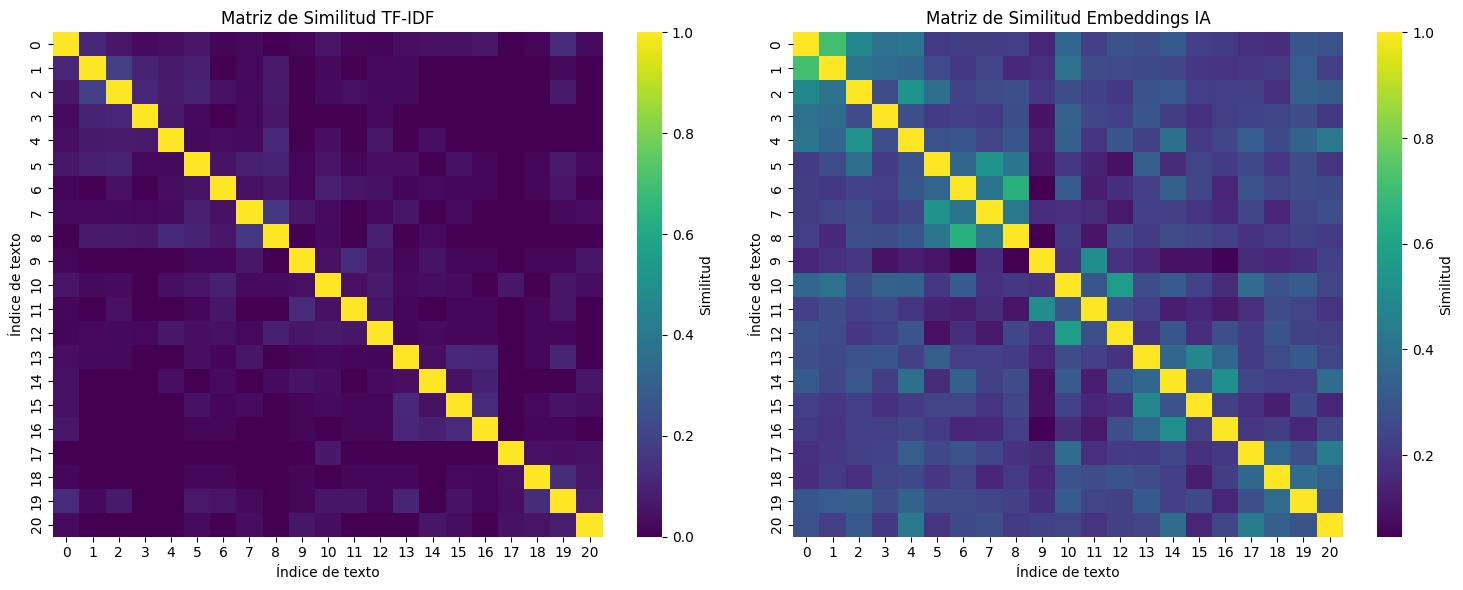

In [24]:
print("GENERANDO VISUALIZACIONES")

# Crear visualización de las matrices de similitud
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# TF-IDF heatmap
sns.heatmap(tfidf_similarities,
            annot=False,
            cmap='viridis',
            ax=axes[0],
            cbar_kws={'label': 'Similitud'})
axes[0].set_title('Matriz de Similitud TF-IDF')
axes[0].set_xlabel('Índice de texto')
axes[0].set_ylabel('Índice de texto')

# Embeddings heatmap
sns.heatmap(embeddings_similarities,
            annot=False,
            cmap='viridis',
            ax=axes[1],
            cbar_kws={'label': 'Similitud'})
axes[1].set_title('Matriz de Similitud Embeddings IA')
axes[1].set_xlabel('Índice de texto')
axes[1].set_ylabel('Índice de texto')

plt.tight_layout()
plt.show()

In [25]:
# Obtener solo el triángulo superior (sin diagonal) para evitar autocomparaciones
triu_indices = np.triu_indices_from(tfidf_similarities, k=1)
tfidf_upper = tfidf_similarities[triu_indices]
embeddings_upper = embeddings_similarities[triu_indices]

print(f"Estadísticas TF-IDF:")
print(f"  Media: {np.mean(tfidf_upper):.4f}")
print(f"  Mediana: {np.median(tfidf_upper):.4f}")
print(f"  Std: {np.std(tfidf_upper):.4f}")
print(f"  Min: {np.min(tfidf_upper):.4f}")
print(f"  Max: {np.max(tfidf_upper):.4f}")

print(f"\nEstadísticas Embeddings:")
print(f"  Media: {np.mean(embeddings_upper):.4f}")
print(f"  Mediana: {np.median(embeddings_upper):.4f}")
print(f"  Std: {np.std(embeddings_upper):.4f}")
print(f"  Min: {np.min(embeddings_upper):.4f}")
print(f"  Max: {np.max(embeddings_upper):.4f}")

Estadísticas TF-IDF:
  Media: 0.0302
  Mediana: 0.0201
  Std: 0.0339
  Min: 0.0000
  Max: 0.1837

Estadísticas Embeddings:
  Media: 0.2529
  Mediana: 0.2369
  Std: 0.1012
  Min: 0.0457
  Max: 0.7160
